# Matplotlib & Seaborn — Visualización de Datos

> **Referencia:** Stewart & Mommert, *Python for Scientists* (3ª ed.), Capítulo 6

## ¿Qué es Matplotlib?

**Matplotlib** es la librería de visualización más popular de Python. Fue inspirada por las capacidades gráficas de MATLAB pero es completamente independiente. Permite crear gráficas de calidad de publicación científica con control total sobre cada elemento visual.

- Muy **flexible** y **poderosa**
- Base de muchas otras librerías de visualización
- Dos interfaces: **procedural** (`plt.plot()`) y **orientada a objetos** (`ax.plot()`)

## ¿Qué es Seaborn?

**Seaborn** está construida **sobre** Matplotlib. Su objetivo es hacer visualizaciones estadísticas atractivas con menos código.

- Gráficas más **estéticas** por defecto
- Integración directa con **DataFrames de Pandas**
- Ideal para **análisis exploratorio de datos**

| Característica | Matplotlib | Seaborn |
|---|---|---|
| Control | Total | Moderado |
| Código necesario | Más | Menos |
| Estética por defecto | Básica | Profesional |
| Integración con Pandas | Manual | Directa |

## Instalación e Importación

```bash
pip install matplotlib seaborn
```

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

%matplotlib inline

print("Matplotlib versión:", __import__('matplotlib').__version__)
print("Seaborn versión:",    sns.__version__)

Matplotlib versión: 3.10.8
Seaborn versión: 0.13.2


---
## Parte 1 — Matplotlib

### Nivel 1 — Gráfica de línea básica

La gráfica más simple solo requiere `plt.plot(x, y)` y `plt.show()`.  
Personalización básica: `color`, `linewidth`, `linestyle`, `label`.

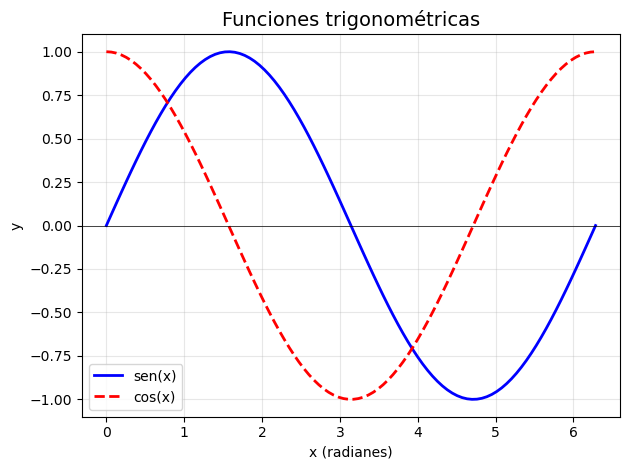

In [8]:
# La gráfica más simple
x = np.linspace(0, 2 * np.pi, 100)

plt.plot(x, np.sin(x), color='blue',  linewidth=2, label='sen(x)')
plt.plot(x, np.cos(x), color='red',   linewidth=2, label='cos(x)', linestyle='--')

plt.title('Funciones trigonométricas', fontsize=14)
plt.xlabel('x (radianes)')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### Nivel 2 — Interfaz Orientada a Objetos (recomendada)

> **§6.2 Stewart & Mommert** — El libro recomienda usar la interfaz OO para todo excepto gráficas simples.

La interfaz procedural (`plt.plot()`) es conveniente pero limitada.  
La interfaz **orientada a objetos** trabaja con dos objetos:

- **`Figure`** (`fig`): el lienzo completo, como una hoja de papel
- **`Axes`** (`ax`): un sistema de coordenadas dentro del lienzo

```python
fig, ax = plt.subplots()   # crear figura + un axes
ax.plot(x, y)              # graficar en ese axes
ax.set_xlabel('x')         # nota: set_ en vez de plt.
ax.set_ylabel('y')
ax.set_title('título')
```

| `plt.` (procedural) | `ax.` (OO) |
|---|---|
| `plt.xlabel()` | `ax.set_xlabel()` |
| `plt.ylabel()` | `ax.set_ylabel()` |
| `plt.title()` | `ax.set_title()` |
| `plt.xlim()` | `ax.set_xlim()` |
| `plt.ylim()` | `ax.set_ylim()` |

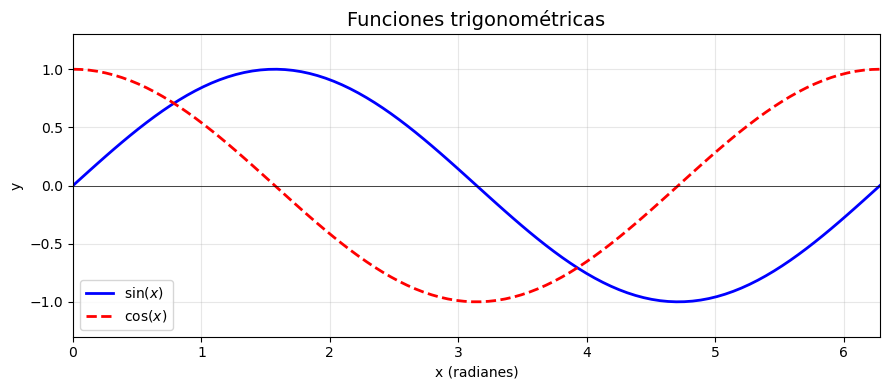

In [18]:
# Misma gráfica, ahora con interfaz OO
x = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(x, np.sin(x), color='blue', linewidth=2, label=r'$\sin(x)$')
ax.plot(x, np.cos(x), color='red',  linewidth=2, label=r'$\cos(x)$', linestyle='--')

ax.set_title('Funciones trigonométricas', fontsize=14)
ax.set_xlabel('x (radianes)')
ax.set_ylabel('y')
ax.set_xlim(0, 2 * np.pi)   # rango del eje x
ax.set_ylim(-1.3, 1.3)       # rango del eje y
ax.axhline(0, color='black', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Nivel 3 — Personalización avanzada

#### 3a — Fórmulas matemáticas en etiquetas (LaTeX)

Matplotlib soporta LaTeX en cualquier texto usando `r'$...$'`.

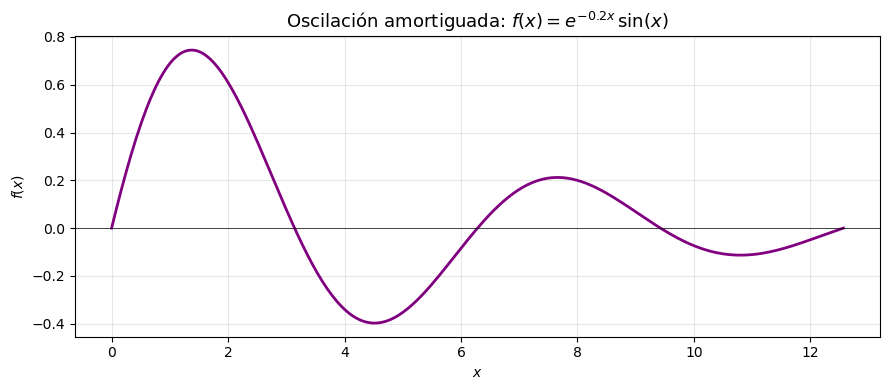

In [20]:
# Fórmulas matemáticas con LaTeX en etiquetas
x = np.linspace(0, 4 * np.pi, 300)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(x, np.exp(-0.2 * x) * np.sin(x), color='purple', linewidth=2)

# LaTeX en title y labels
ax.set_title(r'Oscilación amortiguada: $f(x) = e^{-0.2x}\,\sin(x)$', fontsize=13)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$f(x)$')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

#### 3b — Anotaciones (`ax.annotate` y `ax.text`)

> **§6.3.8** — Las anotaciones permiten señalar puntos específicos con texto y flechas.

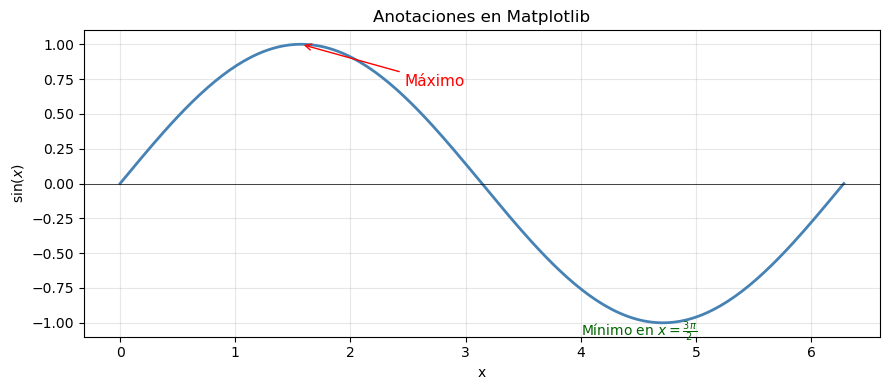

In [26]:
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, color='steelblue', linewidth=2)

# ax.annotate: texto + flecha apuntando a un punto
ax.annotate(
    'Máximo',
    xy=(np.pi / 2, 1),           # punta de la flecha
    xytext=(np.pi / 2 + 0.9, 0.7),  # posición del texto
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=11, color='red'
)

# ax.text: texto simple sin flecha
ax.text(4.0, -1.1, r'Mínimo en $x=\frac{3\pi}{2}$', fontsize=10, color='darkgreen')

ax.set_title('Anotaciones en Matplotlib')
ax.set_xlabel('x')
ax.set_ylabel(r'$\sin(x)$')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

#### 3c — Áreas rellenas (`fill_between`) y barras de error (`errorbar`)

> **§6.4.3–6.4.4** del libro.

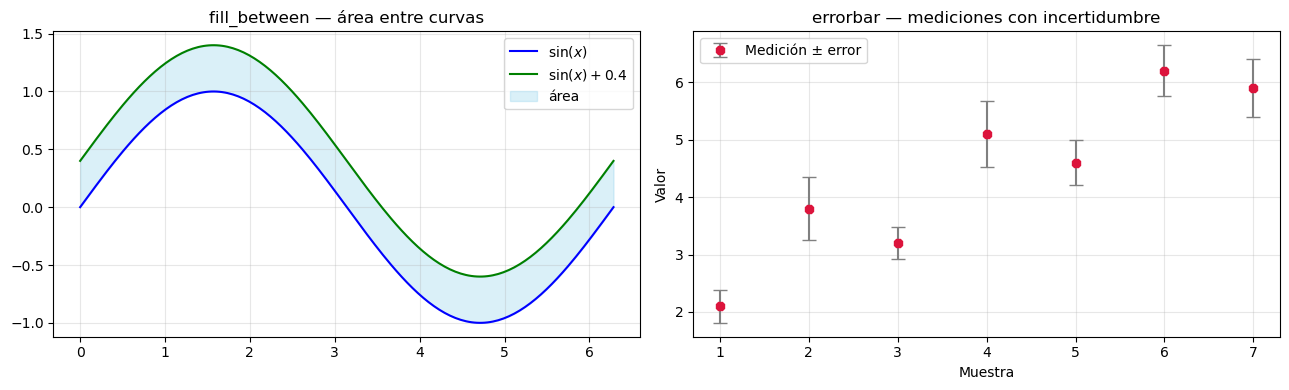

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── fill_between: área entre dos curvas ──────────────────────────────────────
x = np.linspace(0, 2 * np.pi, 200)
y1 = np.sin(x)
y2 = np.sin(x) + 0.4

axes[0].plot(x, y1, color='blue',  label=r'$\sin(x)$')
axes[0].plot(x, y2, color='green', label=r'$\sin(x)+0.4$')
axes[0].fill_between(x, y1, y2, alpha=0.3, color='skyblue', label='área')
axes[0].set_title('fill_between — área entre curvas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── errorbar: mediciones con incertidumbre ────────────────────────────────────
np.random.seed(5)
x_datos  = np.arange(1, 8)
y_datos  = np.array([2.1, 3.8, 3.2, 5.1, 4.6, 6.2, 5.9])
y_error  = np.random.uniform(0.2, 0.6, size=7)   # incertidumbre

axes[1].errorbar(x_datos, y_datos, yerr=y_error,
                 fmt='8',             # marcador circular
                 color='crimson',
                 ecolor='gray',       # color barras de error
                 elinewidth=1.5,
                 capsize=5,           # topes en las barras
                 label='Medición ± error')
axes[1].set_title('errorbar — mediciones con incertidumbre')
axes[1].set_xlabel('Muestra')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 3d — Escala logarítmica

> **§6.3.2** — Útil cuando los datos abarcan varios órdenes de magnitud.

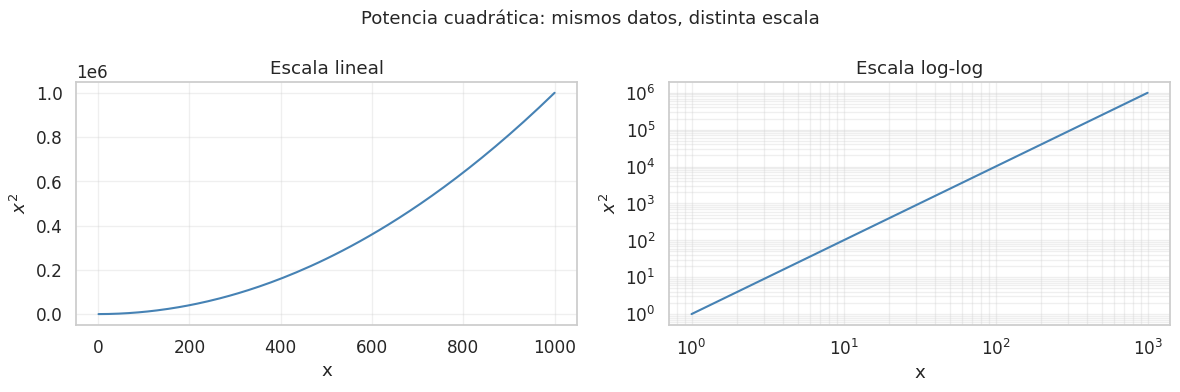

In [48]:
x = np.logspace(0, 3, 200)   # 1 a 1000

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Escala lineal
axes[0].plot(x, x**2, color='steelblue')
axes[0].set_title('Escala lineal')
axes[0].set_xlabel('x')
axes[0].set_ylabel(r'$x^2$')
axes[0].grid(True, alpha=0.3)

# Escala log-log
axes[1].plot(x, x**2, color='steelblue')
axes[1].set_xscale('log')   # eje x logarítmico
axes[1].set_yscale('log')   # eje y logarítmico
axes[1].set_title('Escala log-log')
axes[1].set_xlabel('x')
axes[1].set_ylabel(r'$x^2$')
axes[1].grid(True, which='both', alpha=0.3)  # grid en escala log

fig.suptitle('Potencia cuadrática: mismos datos, distinta escala', fontsize=13)
plt.tight_layout()
plt.show()

### Nivel 4 — Tipos de gráficas

#### 4a — Gráfica de barras

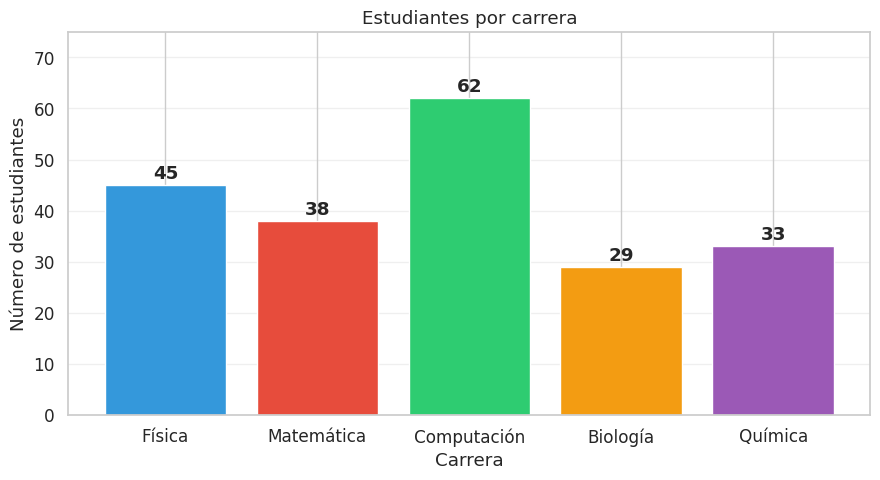

In [53]:
carreras    = ['Física', 'Matemática', 'Computación', 'Biología', 'Química']
estudiantes = [45, 38, 62, 29, 33]

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(carreras, estudiantes,
                color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'])

# Valor encima de cada barra
for barra, valor in zip(barras, estudiantes):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.5,
            str(valor), ha='center', va='bottom', fontweight='bold')

ax.set_title('Estudiantes por carrera')
ax.set_xlabel('Carrera')
ax.set_ylabel('Número de estudiantes')
ax.set_ylim(0, 75)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

#### 4b — Histograma y dispersión (scatter)

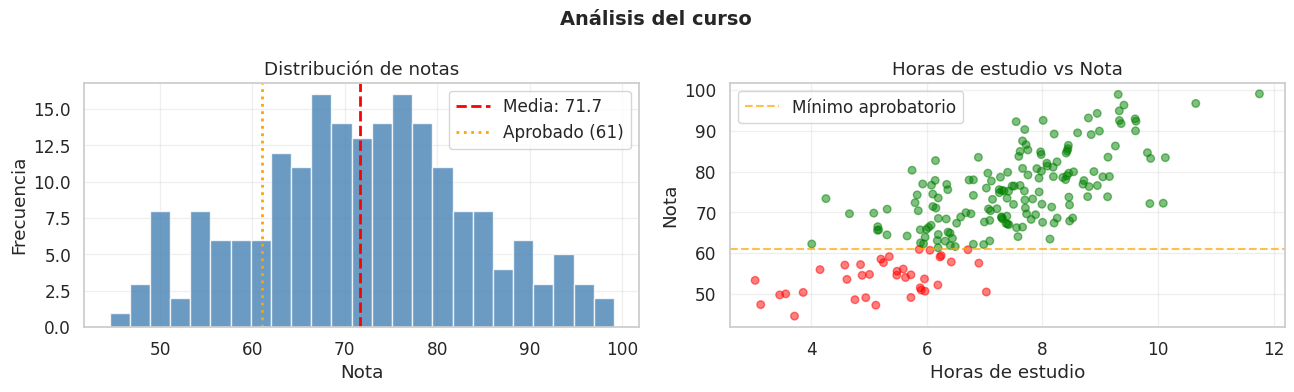

In [54]:
np.random.seed(7)
notas = np.random.normal(loc=72, scale=12, size=200).clip(0, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Histograma ────────────────────────────────────────────────────────────────
axes[0].hist(notas, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(notas.mean(), color='red',    linestyle='--', linewidth=2,
                label=f'Media: {notas.mean():.1f}')
axes[0].axvline(61,           color='orange', linestyle=':',  linewidth=2,
                label='Aprobado (61)')
axes[0].set_title('Distribución de notas')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Scatter ───────────────────────────────────────────────────────────────────
horas = (notas / 10 + np.random.normal(0, 1, 200))
colores = ['green' if n >= 61 else 'red' for n in notas]

axes[1].scatter(horas, notas, c=colores, alpha=0.5, s=30)
axes[1].axhline(61, color='orange', linestyle='--', alpha=0.7, label='Mínimo aprobatorio')
axes[1].set_title('Horas de estudio vs Nota')
axes[1].set_xlabel('Horas de estudio')
axes[1].set_ylabel('Nota')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Análisis del curso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 4c — Pastel (pie) y diagrama de caja (boxplot)

In [62]:
grupos = [
    notas[notas < 61],
    notas[(notas >= 61) & (notas < 80)],
    notas[notas >= 80]
]

/tmp/ipykernel_142330/1142614638.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(grupos, labels=etiquetas, patch_artist=True,


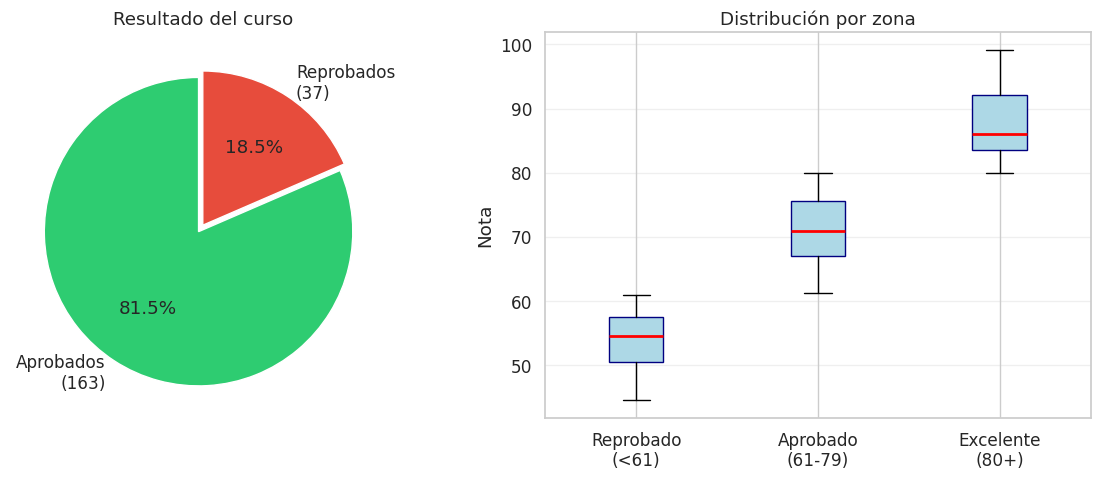

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Pie chart ────────────────────────────────────────────────────────────────
aprobados  = int(np.sum(notas >= 61))
reprobados = len(notas) - aprobados

axes[0].pie(
    [aprobados, reprobados],
    labels=[f'Aprobados\n({aprobados})', f'Reprobados\n({reprobados})'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
axes[0].set_title('Resultado del curso')

# ── Box plot ─────────────────────────────────────────────────────────────────
grupos = [
    notas[notas < 61],
    notas[(notas >= 61) & (notas < 80)],
    notas[notas >= 80]
]
etiquetas = ['Reprobado\n(<61)', 'Aprobado\n(61-79)', 'Excelente\n(80+)']

axes[1].boxplot(grupos, labels=etiquetas, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Distribución por zona')
axes[1].set_ylabel('Nota')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Nivel 5 — Figuras compuestas (subplots)

> **§6.8** — `plt.subplots(filas, columnas)` crea una grilla de `Axes`.

Cuando hay más de una fila y columna, `axes` es un array 2D: `axes[fila, columna]`.

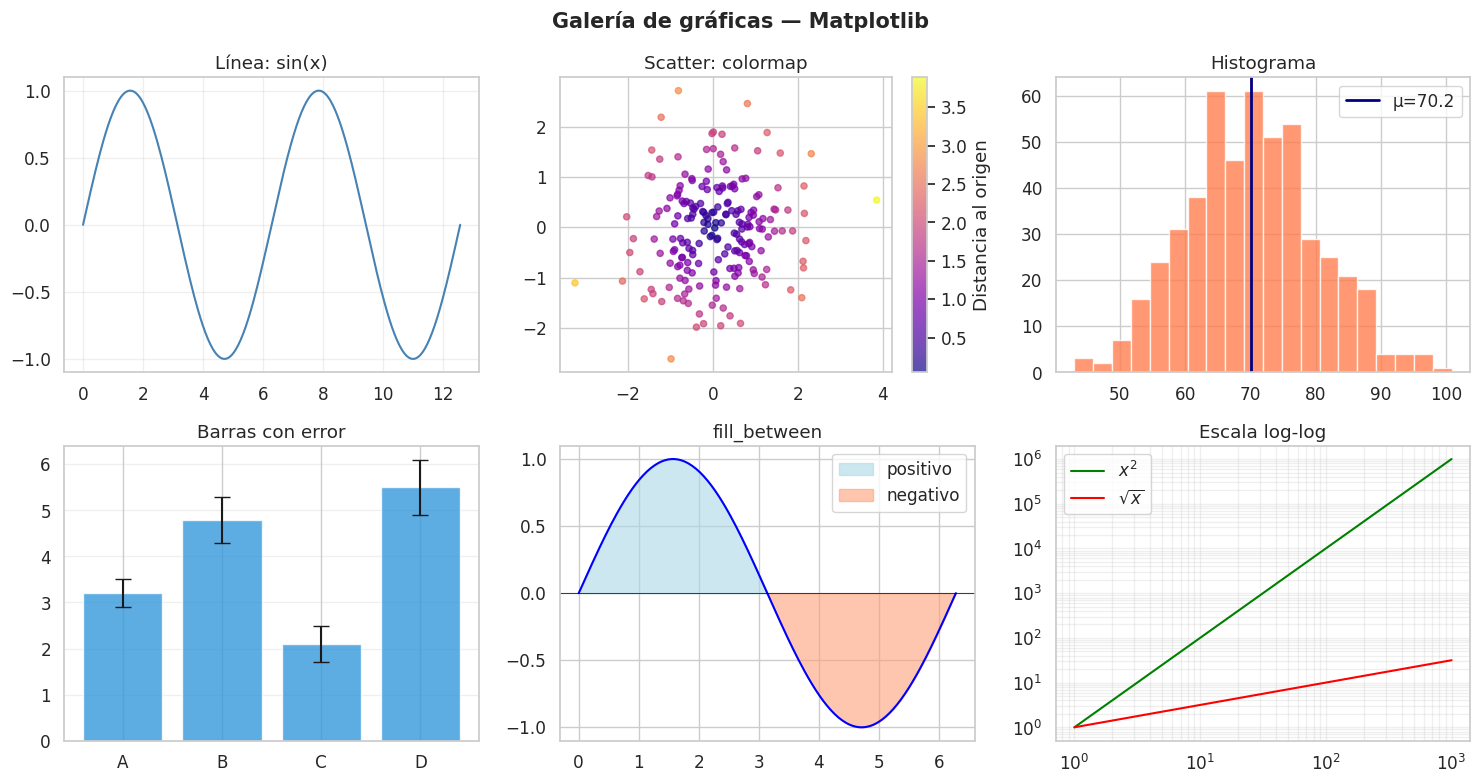

In [63]:
np.random.seed(42)
x = np.linspace(0, 4 * np.pi, 300)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Galería de gráficas — Matplotlib', fontsize=15, fontweight='bold')

# [0,0] Línea
axes[0, 0].plot(x, np.sin(x), color='steelblue')
axes[0, 0].set_title('Línea: sin(x)')
axes[0, 0].grid(True, alpha=0.3)

# [0,1] Scatter con color por valor
y_sc = np.random.normal(0, 1, 200)
x_sc = np.random.normal(0, 1, 200)
c_sc = np.sqrt(x_sc**2 + y_sc**2)
sc = axes[0, 1].scatter(x_sc, y_sc, c=c_sc, cmap='plasma', alpha=0.7, s=20)
fig.colorbar(sc, ax=axes[0, 1], label='Distancia al origen')
axes[0, 1].set_title('Scatter: colormap')

# [0,2] Histograma
datos = np.random.normal(70, 10, 500)
axes[0, 2].hist(datos, bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[0, 2].axvline(datos.mean(), color='navy', linewidth=2, label=f'μ={datos.mean():.1f}')
axes[0, 2].legend()
axes[0, 2].set_title('Histograma')

# [1,0] Barras con error
cats  = ['A', 'B', 'C', 'D']
vals  = [3.2, 4.8, 2.1, 5.5]
errs  = [0.3, 0.5, 0.4, 0.6]
axes[1, 0].bar(cats, vals, yerr=errs, color='#3498db', capsize=6, alpha=0.8)
axes[1, 0].set_title('Barras con error')
axes[1, 0].grid(axis='y', alpha=0.3)

# [1,1] fill_between
t  = np.linspace(0, 2 * np.pi, 200)
y0 = np.sin(t)
axes[1, 1].plot(t, y0, color='blue')
axes[1, 1].fill_between(t, y0, 0, where=(y0 > 0), color='lightblue',  alpha=0.6, label='positivo')
axes[1, 1].fill_between(t, y0, 0, where=(y0 < 0), color='lightsalmon', alpha=0.6, label='negativo')
axes[1, 1].axhline(0, color='black', linewidth=0.5)
axes[1, 1].legend()
axes[1, 1].set_title('fill_between')

# [1,2] Log-log
xlog = np.logspace(0, 3, 100)
axes[1, 2].loglog(xlog, xlog**2,   color='green', label=r'$x^2$')
axes[1, 2].loglog(xlog, xlog**0.5, color='red',   label=r'$\sqrt{x}$')
axes[1, 2].legend()
axes[1, 2].set_title('Escala log-log')
axes[1, 2].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Parte 2 — Seaborn

Seaborn trabaja mejor con DataFrames de Pandas. Creamos primero un dataset de ejemplo:

In [64]:
np.random.seed(42)
n = 160

df = pd.DataFrame({
    'Nombre':        [f'Est_{i:03d}' for i in range(n)],
    'Carrera':       np.random.choice(['Física', 'Matemática', 'Computación'], size=n),
    'Semestre':      np.random.choice([1, 2, 3, 4, 5, 6, 7, 8], size=n),
    'Horas_estudio': np.random.normal(5, 2, n).clip(0, 12).round(1),
    'Nota':          np.random.normal(72, 14, n).clip(40, 100).round(1),
})

df['Nota']   = (df['Nota'] + df['Horas_estudio'] * 1.5).clip(40, 100).round(1)
df['Estado'] = df['Nota'].apply(lambda n: 'Aprobado' if n >= 61 else 'Reprobado')

print('Dataset creado:')
print(df.head())
print(f'\nShape: {df.shape}')

Dataset creado:
    Nombre      Carrera  Semestre  Horas_estudio  Nota    Estado
0  Est_000  Computación         3            5.5  80.0  Aprobado
1  Est_001       Física         3            6.6  83.5  Aprobado
2  Est_002  Computación         6            2.5  93.6  Aprobado
3  Est_003  Computación         4            2.4  67.3  Aprobado
4  Est_004       Física         2            6.0  88.7  Aprobado

Shape: (160, 6)


### Nivel 1 — Configurar el estilo

Estilos disponibles: `whitegrid`, `darkgrid`, `white`, `dark`, `ticks`

In [65]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Tema configurado.')

Tema configurado.


### Nivel 2 — Distribuciones: `histplot` y `boxplot`

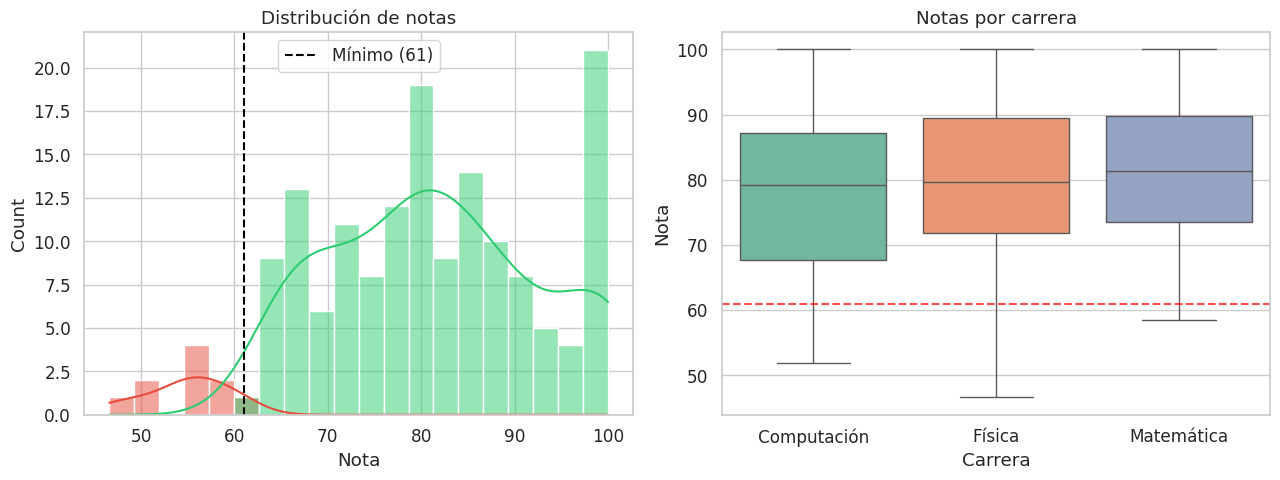

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# histplot con KDE y separación por estado
sns.histplot(data=df, x='Nota', hue='Estado', bins=20, kde=True,
             palette={'Aprobado': '#2ecc71', 'Reprobado': '#e74c3c'},
             ax=axes[0])
axes[0].axvline(61, color='black', linestyle='--', linewidth=1.5, label='Mínimo (61)')
axes[0].set_title('Distribución de notas')
axes[0].legend()

# boxplot comparativo por carrera
sns.boxplot(data=df, x='Carrera', y='Nota', hue='Carrera',
            palette='Set2', ax=axes[1], legend=False)
axes[1].axhline(61, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_title('Notas por carrera')

plt.tight_layout()
plt.show()

### Nivel 3 — Relaciones: `regplot` y `violinplot`

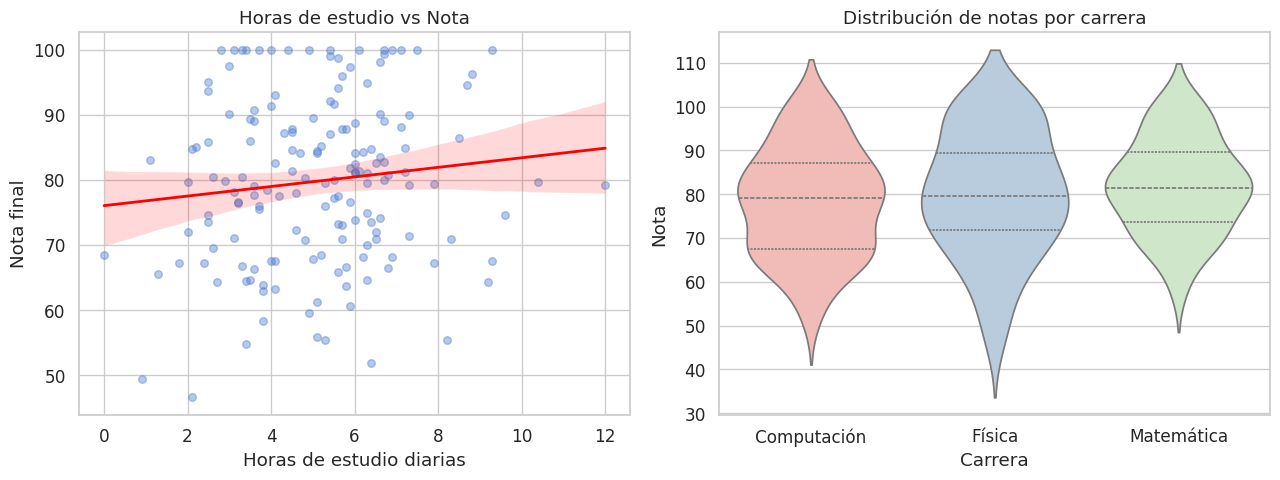

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# regplot: dispersión + línea de regresión
sns.regplot(data=df, x='Horas_estudio', y='Nota',
            scatter_kws={'alpha': 0.4, 's': 30},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=axes[0])
axes[0].set_title('Horas de estudio vs Nota')
axes[0].set_xlabel('Horas de estudio diarias')
axes[0].set_ylabel('Nota final')

# violinplot: distribución más detallada que boxplot
sns.violinplot(data=df, x='Carrera', y='Nota', hue='Carrera',
               palette='Pastel1', inner='quartile',
               ax=axes[1], legend=False)
axes[1].set_title('Distribución de notas por carrera')

plt.tight_layout()
plt.show()

### Nivel 4 — Conteos y comparaciones: `countplot` y `barplot`

In [70]:
df

,Nombre,Carrera,Semestre,Horas_estudio,Nota,Estado
0,Est_000,Computación,3,5.5,80.0,Aprobado
1,Est_001,Física,3,6.6,83.5,Aprobado
2,Est_002,Computación,6,2.5,93.6,Aprobado
3,Est_003,Computación,4,2.4,67.3,Aprobado
4,Est_004,Física,2,6.0,88.7,Aprobado
...,...,...,...,...,...,...
155,Est_155,Computación,4,6.3,64.6,Aprobado
156,Est_156,Computación,4,3.3,100.0,Aprobado
157,Est_157,Física,1,3.9,78.4,Aprobado
158,Est_158,Física,2,6.5,72.0,Aprobado


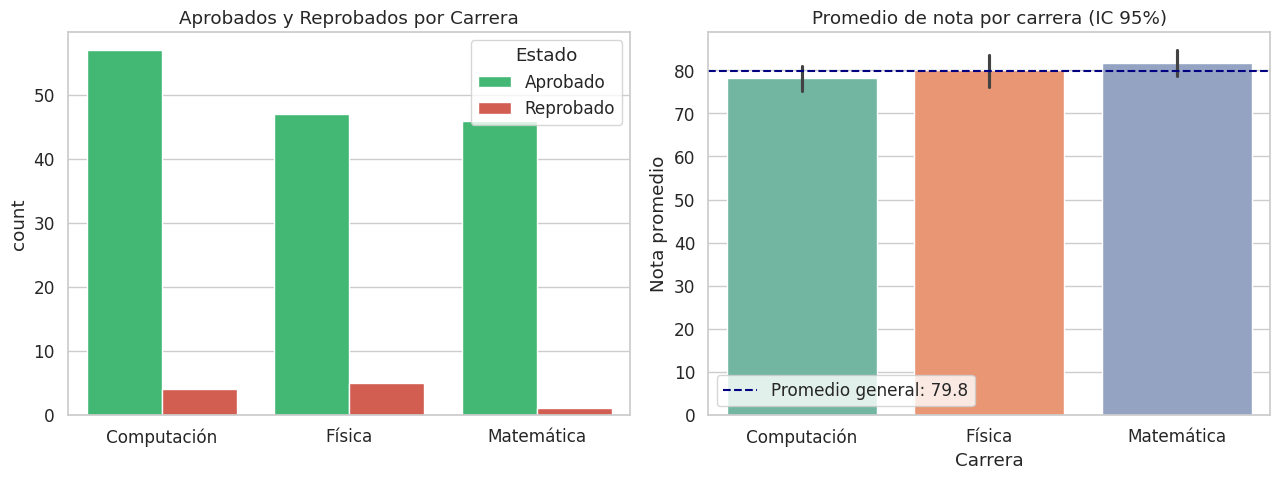

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# countplot: cuenta cuántos hay en cada categoría
sns.countplot(data=df, x='Carrera', hue='Estado',
              palette={'Aprobado': '#2ecc71', 'Reprobado': '#e74c3c'},
              ax=axes[0])
axes[0].set_title('Aprobados y Reprobados por Carrera')
axes[0].set_xlabel('')
axes[0].legend(title='Estado')

# barplot: promedio (con intervalo de confianza) por grupo
# errorbar='ci' muestra el intervalo de confianza del 95%
sns.barplot(data=df, x='Carrera', y='Nota', hue='Carrera',
            palette='Set2', errorbar='ci', legend=False,
            ax=axes[1])
axes[1].axhline(df['Nota'].mean(), color='navy', linestyle='--',
                linewidth=1.5, label=f'Promedio general: {df["Nota"].mean():.1f}')
axes[1].set_title('Promedio de nota por carrera (IC 95%)')
axes[1].set_ylabel('Nota promedio')
axes[1].legend()

plt.tight_layout()
plt.show()

### Nivel 5 — `pairplot`: matriz de gráficas

`pairplot` genera automáticamente todas las combinaciones de variables numéricas.  
Es muy útil para explorar relaciones entre múltiples variables a la vez.

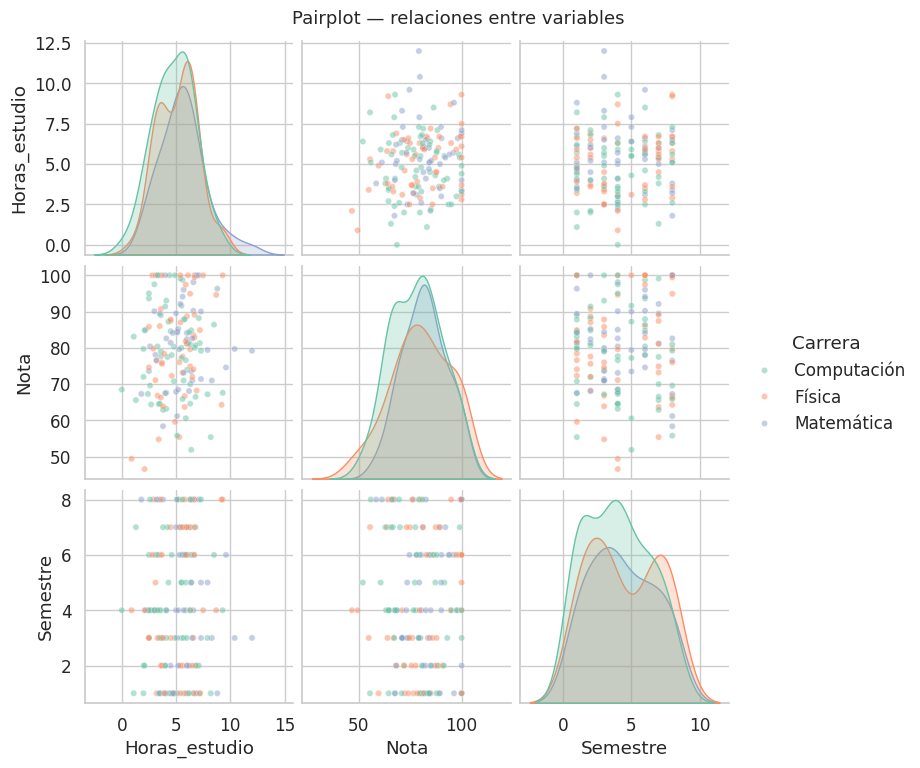

In [72]:
# pairplot sobre variables numéricas, coloreado por carrera
g = sns.pairplot(
    df[['Horas_estudio', 'Nota', 'Semestre', 'Carrera']],
    hue='Carrera',
    palette='Set2',
    diag_kind='kde',      # diagonal: estimación de densidad
    plot_kws={'alpha': 0.5, 's': 20}
)
g.fig.suptitle('Pairplot — relaciones entre variables', y=1.02, fontsize=13)
plt.show()

### Nivel 6 — Heatmap: mapa de calor de correlaciones

In [74]:
df[['Horas_estudio', 'Nota', 'Semestre']].corr()

,Horas_estudio,Nota,Semestre
Horas_estudio,1.000000,0.115506,0.061056
Nota,0.115506,1.000000,-0.000447
Semestre,0.061056,-0.000447,1.000000


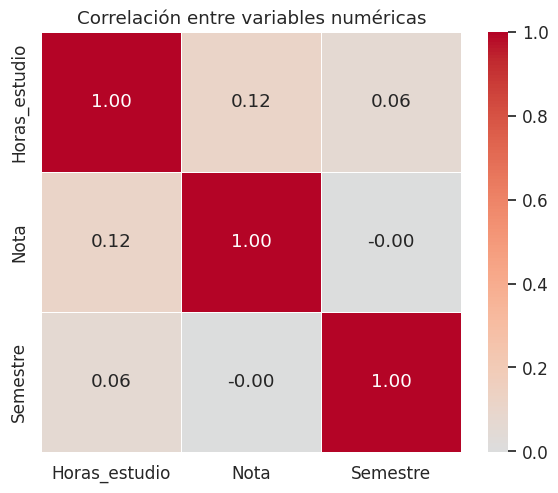

In [73]:
correlacion = df[['Horas_estudio', 'Nota', 'Semestre']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    correlacion,
    annot=True,       # mostrar valores
    fmt='.2f',        # 2 decimales
    cmap='coolwarm',  # azul=negativo, rojo=positivo
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

### Nivel 7 — Dashboard completo

/tmp/ipykernel_142330/1462478582.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Semestre', y='Nota', palette='Blues', ax=axes[1, 0])


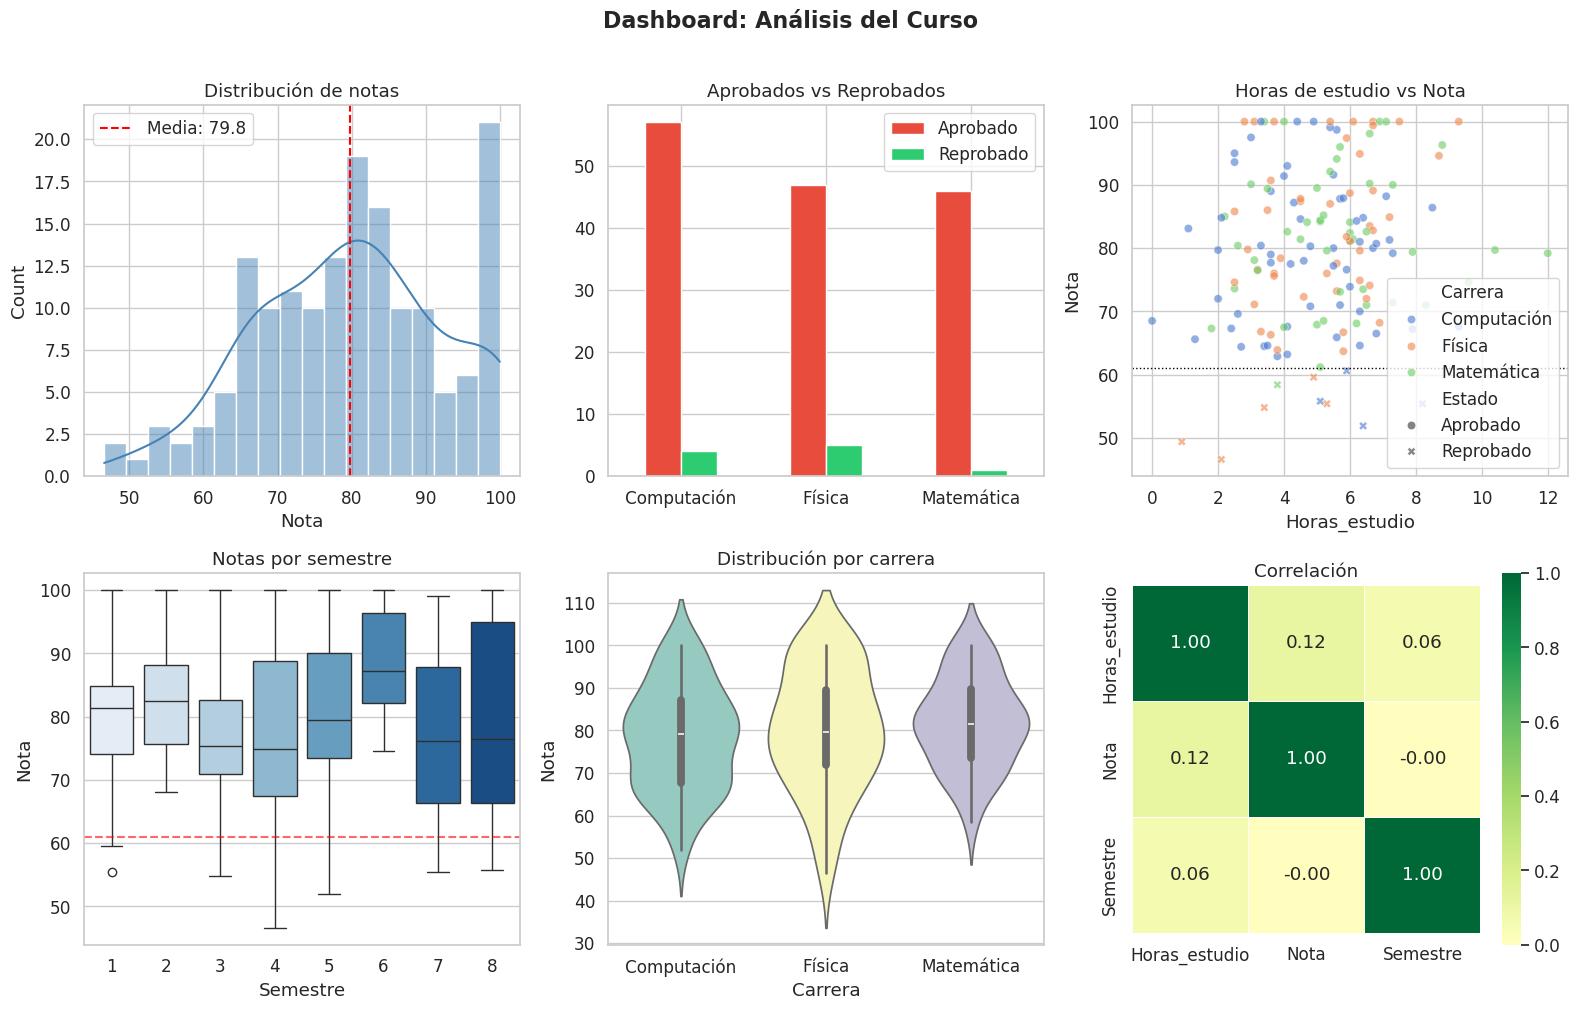

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Dashboard: Análisis del Curso', fontsize=16, fontweight='bold', y=1.01)

# 1. Distribución general
sns.histplot(data=df, x='Nota', bins=18, kde=True, color='steelblue', ax=axes[0, 0])
axes[0, 0].axvline(df['Nota'].mean(), color='red', linestyle='--',
                   label=f'Media: {df["Nota"].mean():.1f}')
axes[0, 0].set_title('Distribución de notas')
axes[0, 0].legend()

# 2. Aprobados vs Reprobados por carrera (barras apiladas)
resultado = df.groupby(['Carrera', 'Estado']).size().unstack(fill_value=0)
resultado.plot(kind='bar', ax=axes[0, 1],
               color=['#e74c3c', '#2ecc71'], edgecolor='white', rot=0)
axes[0, 1].set_title('Aprobados vs Reprobados')
axes[0, 1].set_xlabel('')
axes[0, 1].legend(title='')

# 3. Scatter horas vs nota
sns.scatterplot(data=df, x='Horas_estudio', y='Nota',
                hue='Carrera', style='Estado', alpha=0.6, ax=axes[0, 2])
axes[0, 2].axhline(61, color='black', linestyle=':', linewidth=1)
axes[0, 2].set_title('Horas de estudio vs Nota')

# 4. Boxplot por semestre
sns.boxplot(data=df, x='Semestre', y='Nota', palette='Blues', ax=axes[1, 0])
axes[1, 0].axhline(61, color='red', linestyle='--', alpha=0.6)
axes[1, 0].set_title('Notas por semestre')

# 5. Violinplot por carrera
sns.violinplot(data=df, x='Carrera', y='Nota', hue='Carrera',
               palette='Set3', inner='box', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Distribución por carrera')

# 6. Heatmap
corr = df[['Horas_estudio', 'Nota', 'Semestre']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1, 2], square=True, linewidths=0.5)
axes[1, 2].set_title('Correlación')

plt.tight_layout()
plt.show()

---
## Guardar gráficas

`plt.savefig()` debe llamarse **antes** de `plt.show()`.  
Formatos soportados: `png`, `pdf`, `svg`, `eps`.

Gráfica guardada en /tmp/grafica_notas.png


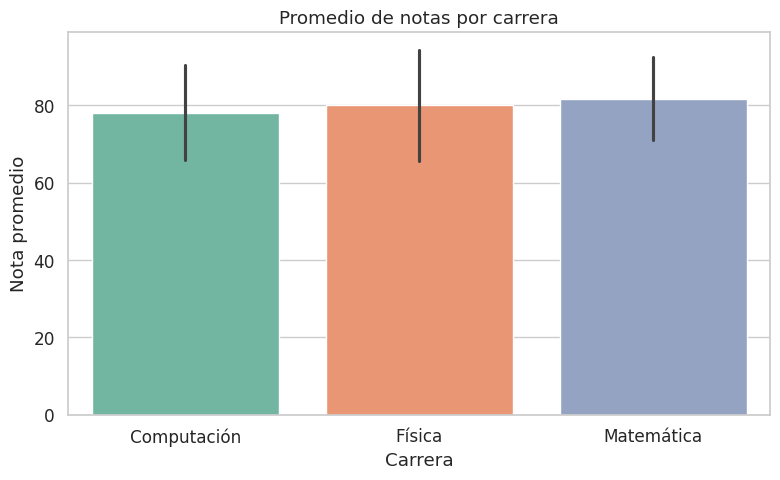

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df, x='Carrera', y='Nota', hue='Carrera',
            palette='Set2', errorbar='sd', legend=False, ax=ax)
ax.set_title('Promedio de notas por carrera')
ax.set_ylabel('Nota promedio')

# dpi=150 para buena resolución; bbox_inches='tight' evita recortes
plt.savefig('grafica_notas.png', dpi=150, bbox_inches='tight')
print('Gráfica guardada en /tmp/grafica_notas.png')

plt.tight_layout()
plt.show()

---
## Resumen de funciones principales

### Matplotlib

| Función | Descripción |
|---|---|
| `plt.subplots(f, c)` | Crear figura con `f` filas y `c` columnas de axes |
| `ax.plot(x, y)` | Gráfica de línea |
| `ax.scatter(x, y)` | Gráfica de dispersión |
| `ax.bar(x, y)` | Gráfica de barras |
| `ax.hist(x, bins)` | Histograma |
| `ax.errorbar(x, y, yerr)` | Línea con barras de error |
| `ax.fill_between(x, y1, y2)` | Área entre dos curvas |
| `ax.annotate(txt, xy, xytext)` | Anotación con flecha |
| `ax.set_xscale('log')` | Escala logarítmica |
| `plt.savefig(ruta, dpi)` | Guardar figura |

### Seaborn

| Función | Descripción |
|---|---|
| `sns.set_theme(style, palette)` | Configurar estilo global |
| `sns.histplot(data, x, hue, kde)` | Histograma con opción de KDE |
| `sns.boxplot(data, x, y, hue)` | Diagrama de caja |
| `sns.violinplot(data, x, y)` | Violín (distribución detallada) |
| `sns.regplot(data, x, y)` | Scatter + línea de regresión |
| `sns.countplot(data, x, hue)` | Conteo de categorías |
| `sns.barplot(data, x, y)` | Promedio por grupo con IC |
| `sns.heatmap(corr, annot)` | Mapa de calor |
| `sns.pairplot(data, hue)` | Matriz de gráficas |
| `sns.scatterplot(data, x, y, hue)` | Scatter con categorías |

---
## Ejercicios

### Ejercicio 1 — Gráfica de línea con personalización

Usando la interfaz orientada a objetos (`fig, ax = plt.subplots()`), grafica las funciones $f(x) = x^2$, $g(x) = x^3$ y $h(x) = \sqrt{x}$ en el rango $[0, 4]$ en una misma figura.

Requisitos:
- Cada curva con diferente color y etiqueta en LaTeX
- Leyenda visible
- Título y etiquetas de ejes con LaTeX
- Cuadrícula con transparencia

In [ ]:
# TU CÓDIGO AQUÍ


### Ejercicio 2 — Subplots y tipos de gráficas

Crea una figura con 2 filas y 2 columnas (`plt.subplots(2, 2, figsize=(12, 8))`) usando el dataset `df` del notebook:

- `[0,0]` Histograma de `Horas_estudio` con línea en la media
- `[0,1]` Scatter de `Horas_estudio` vs `Nota` coloreado por `Carrera`
- `[1,0]` Boxplot de `Nota` por `Semestre`
- `[1,1]` Barras con el promedio de horas de estudio por carrera

Agrega título general con `fig.suptitle()`.

In [ ]:
# TU CÓDIGO AQUÍ


### Ejercicio 3 — Seaborn exploratorio

Con el dataset `df`, crea una figura con 3 gráficas de Seaborn:

a) `violinplot` de `Nota` por `Carrera`, separado por `Estado` (usa `hue='Estado'`)  
b) `countplot` de `Semestre` coloreado por `Estado`  
c) `heatmap` de correlación entre `Horas_estudio`, `Nota` y `Semestre`

Cada gráfica debe tener título.

In [ ]:
# TU CÓDIGO AQUÍ


### Ejercicio 4 — Datos reales con barras de error

Se midió la temperatura promedio mensual (°C) en Ciudad de Guatemala durante un año.  
Los datos incluyen incertidumbre de medición:

```python
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
temp  = [18.2, 19.5, 21.3, 22.8, 22.1, 20.4, 19.8, 20.1, 19.7, 19.3, 18.8, 18.1]
error = [0.8,  0.6,  1.1,  0.9,  1.0,  0.7,  0.8,  0.9,  0.7,  0.6,  0.8,  0.7]
```

a) Grafica la temperatura con `errorbar` (barras de error), marcador circular, y área sombreada con `fill_between` entre `temp - error` y `temp + error`.  
b) Agrega una línea horizontal en el promedio anual con `axhline`.  
c) Anota el mes más caluroso y el más frío con `ax.annotate()`.

In [ ]:
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
temp  = [18.2, 19.5, 21.3, 22.8, 22.1, 20.4, 19.8, 20.1, 19.7, 19.3, 18.8, 18.1]
error = [0.8,  0.6,  1.1,  0.9,  1.0,  0.7,  0.8,  0.9,  0.7,  0.6,  0.8,  0.7]

# TU CÓDIGO AQUÍ
